<a href="https://colab.research.google.com/github/Lavanyajoyce/Ex1-AAI/blob/main/Experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logesh.N.A
212223240078

In [2]:
pip install pybbn

  Preparing metadata (setup.py) ... done
  Created wheel for pybbn: filename=pybbn-3.2.3-py3-none-any.whl size=40372 sha256=d0c34186e06a3d8e36c49423f4aeff56bcc629b2bc88b7df0b8e2bebea1f969c
  Stored in directory: /root/.cache/pip/wheels/97/20/85/52b65994184561eecc73318b47effb93e250a3dc3264db32c9
Successfully built pybbn


In [3]:
import pandas as pd  # for data manipulation
import networkx as nx  # for drawing graphs
import matplotlib.pyplot as plt  # for drawing graphs

from pybbn.graph.dag import Bbn
from pybbn.graph.edge import Edge, EdgeType
from pybbn.graph.jointree import EvidenceBuilder
from pybbn.graph.node import BbnNode
from pybbn.graph.variable import Variable
from pybbn.pptc.inferencecontroller import InferenceController

pd.options.display.max_columns = 50

In [4]:
# Step 3: Read the weather dataset

df = pd.read_csv("/content/weatherAUS.csv")

In [5]:
# Step 4: Remove rows where RainTomorrow is missing

df = df.dropna(subset=["RainTomorrow"])

In [6]:
# Step 5: Fill missing numerical values with column mean

df = df.fillna(df.mean(numeric_only=True))

In [7]:
# Step 6: Create Humidity and Temperature bands

df["HumidityBand"] = pd.cut(
    df["Humidity3pm"],
    bins=[0, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

df["TempBand"] = pd.cut(
    df["Temp3pm"],
    bins=[-10, 20, 30, 50],
    labels=["Low", "Medium", "High"]
)

In [8]:
# Step 7: Display first five rows

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,HumidityBand,TempBand
0,2008-12-01,Albury,13.4,22.9,0.6,5.469824,7.624853,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,No,No,Low,Medium
1,2008-12-02,Albury,7.4,25.1,0.0,5.469824,7.624853,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,No,No,Low,Medium
2,2008-12-03,Albury,12.9,25.7,0.0,5.469824,7.624853,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,No,No,Low,Medium
3,2008-12-04,Albury,9.2,28.0,0.0,5.469824,7.624853,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,No,No,Low,Medium
4,2008-12-05,Albury,17.5,32.3,1.0,5.469824,7.624853,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,No,No,Medium,Medium


In [9]:
# This function helps to calculate probability distribution, which goes into BBN (note, can handle up to 2 parents)

def get_probs(data, child, parents=[]):

    if len(parents) == 0:
        probs = data[child].value_counts(normalize=True).sort_index()
        return probs.values.tolist()

    elif len(parents) == 1:
        probs = pd.crosstab(
            data[parents[0]],
            data[child],
            normalize="index"
        ).sort_index()

        return probs.values.flatten().tolist()

    elif len(parents) == 2:
        probs = pd.crosstab(
            [data[parents[0]], data[parents[1]]],
            data[child],
            normalize="index"
        ).sort_index()

        return probs.values.flatten().tolist()

In [10]:
# Create nodes by using our earlier function to automatically calculate probabilities

humidity = BbnNode(
    Variable(0, "HumidityBand", ["Low", "Medium", "High"]),
    get_probs(df, "HumidityBand")
)

temp = BbnNode(
    Variable(1, "TempBand", ["Low", "Medium", "High"]),
    get_probs(df, "TempBand")
)

rain = BbnNode(
    Variable(2, "RainTomorrow", ["No", "Yes"]),
    get_probs(df, "RainTomorrow", ["HumidityBand", "TempBand"])
)

In [11]:
# Create Network

bbn = Bbn()

bbn.add_node(humidity)
bbn.add_node(temp)
bbn.add_node(rain)

bbn.add_edge(Edge(humidity, rain, EdgeType.DIRECTED))
bbn.add_edge(Edge(temp, rain, EdgeType.DIRECTED))

In [12]:
# Convert the BBN to a join tree

join_tree = InferenceController.apply(bbn)

In [13]:
# Set node positions

pos = {
    "HumidityBand": (0, 1),
    "TempBand": (2, 1),
    "RainTomorrow": (1, 0)
}

In [14]:
# Set options for graph looks

plt.figure(figsize=(8,5))

G = nx.DiGraph()

G.add_edge("HumidityBand", "RainTomorrow")
G.add_edge("TempBand", "RainTomorrow")

<Figure size 800x500 with 0 Axes>

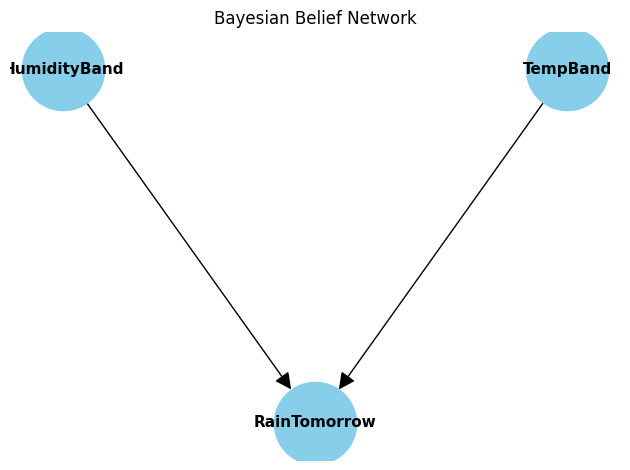

In [17]:
# Generate graph

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=3500,
    font_size=11,
    font_weight="bold",
    arrows=True,
    arrowsize=25
)

# Update margins and print the graph

plt.title("Bayesian Belief Network")
plt.axis("off")
plt.tight_layout()
plt.show()